# **DEEPIKA N K, 242VMBR51320, SEM 3** #

# <u>**Cellphone Data Analysis**</u>

## Step 1-> Libraries & Setup
## Step 2-> Load Dataset
## Step 3-> Data Preprocessing
## Step 4-> Data Exploration and Visualization
## Step 5-> Statistical Analysis
## Step 6-> Summary of the Findings

**Dataset:** <u>cellphone_data.csv</u> — 990 records × 22 features  
**Objective:** Understand data distributions, detect outliers, and conduct hypothesis testing (T-tests, ANOVA, Chi-Square).


--------------------------------------------

## <u> **Step 1-> Libraries & Setup**</u>

In [87]:
# Importing all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')


sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
print("Libraries loaded successfully.")

Libraries loaded successfully.


--------------------------------------------

## <u> Step 2-> Load Dataset</u>

In [88]:
# Loading the dataset
df = pd.read_csv('cellphone_data.csv')

# Display basic info
print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nFirst 5 rows:")
df.head()

Dataset Shape: 990 rows × 22 columns

First 5 rows:


,user_id,cellphone_id,rating,brand,model,operating system,internal memory,RAM,performance,main camera,...,screen size,weight,price(INR),release date,user_name,Region(City),Salary_in_INR,age,gender,occupation
0,0,30,1,Motorola,Moto G Play (2021),Android,32,3,1.42,13,...,6.5,204,13888.65,14/01/2021,Ram,Delhi,570500,38,Female,Data analyst
1,0,5,3,Apple,iPhone XR,iOS,64,3,4.22,12,...,6.1,194,20614.60,26/10/2018,Ram,Delhi,570500,38,Female,Data analyst
2,0,10,9,Samsung,Galaxy S22,Android,128,8,8.81,50,...,6.1,167,46120.80,25/02/2022,Ram,Delhi,570500,38,Female,Data analyst
3,0,9,3,Samsung,Galaxy A53,Android,128,6,3.79,64,...,6.5,189,27253.20,24/03/2022,Ram,Delhi,570500,38,Female,Data analyst
4,0,23,2,Vivo,X80 Pro,Android,256,8,9.81,50,...,6.7,215,76169.20,29/04/2022,Ram,Delhi,570500,38,Female,Data analyst


-------------------------------------------------------------------

## <u> Step 3-> Data Preprocessing</u>


The foundational stage of **"Data Hygiene"** where raw data is cleaned, structured, and validated to ensure that subsequent business decisions are based on accurate information rather than "noise."

Preprocessing focuses solely on **identifying** issues — no treatment is applied at this stage.

### <u> **3.1 Data Types & Basic Description**</u>

In [89]:
# Checking for data types and non-null counts
print("Dataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 990 entries, 0 to 989
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           990 non-null    int64  
 1   cellphone_id      990 non-null    int64  
 2   rating            990 non-null    int64  
 3   brand             990 non-null    object 
 4   model             990 non-null    object 
 5   operating system  990 non-null    object 
 6   internal memory   990 non-null    int64  
 7   RAM               990 non-null    int64  
 8   performance       990 non-null    float64
 9   main camera       990 non-null    int64  
 10  selfie camera     990 non-null    int64  
 11  battery size      990 non-null    int64  
 12  screen size       990 non-null    float64
 13  weight            990 non-null    int64  
 14  price(INR)        990 non-null    float64
 15  release date      990 non-null    object 
 16  user_name         990 non-null

In [90]:
# Statistical summary for numerical columns
print("Statistical Summary (Numerical Variables):")
df.describe().T.round(2)

Statistical Summary (Numerical Variables):


,count,mean,std,min,25%,50%,75%,max
user_id,990.0,136.37,80.66,0.00,74.00,128.00,226.00,258.0
cellphone_id,990.0,16.42,9.47,0.00,8.00,16.00,25.00,32.0
rating,990.0,6.69,2.62,1.00,5.00,7.00,9.00,10.0
internal memory,990.0,145.03,89.31,32.00,128.00,128.00,128.00,512.0
RAM,990.0,6.70,2.67,3.00,4.00,8.00,8.00,12.0
performance,990.0,6.01,2.87,1.02,3.79,6.82,7.94,11.0
main camera,990.0,42.24,26.69,12.00,12.00,50.00,50.00,108.0
selfie camera,990.0,15.37,9.86,4.00,8.00,12.00,16.00,40.0
battery size,990.0,4376.20,763.26,2018.00,4000.00,4600.00,5000.00,5003.0
screen size,990.0,6.45,0.42,4.70,6.40,6.50,6.70,7.6


### <u>**3.2 Missing Values**</u>

In [91]:
# Checking for missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0] if missing_df['Missing Count'].sum() > 0 else "No missing values found in the dataset.")


No missing values found in the dataset.


<u>**Interpretation:**</u> The dataset contains **no missing values** across all 22 columns. 
All 990 records are complete, so no imputation or removal is required at this stage.

### <u>**3.3 Duplicate Entries**</u>

In [92]:
# Checking for duplicate rows
n_duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {n_duplicates}")

# Checking for duplicate user-cellphone combinations (logical duplicates)
n_dup_combo = df.duplicated(subset=['user_id', 'cellphone_id']).sum()
print(f"Duplicate (user_id + cellphone_id) combinations: {n_dup_combo}")


Total duplicate rows: 0
Duplicate (user_id + cellphone_id) combinations: 0


<u>**Interpretation:**</u> There are **no fully duplicated rows** in the dataset. 
The same user can appear multiple times for different cellphones, which is expected (each row = one review).This ensures that the dataset does not contain redundant records that could bias the analysis.


### <u>**3.4 Data Type Verification**</u>

In [93]:
# Identifying numerical and categorical columns
num_cols = df.select_dtypes(include=['number']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical columns ({len(num_cols)}):")
for c in num_cols:
    print(f"  {c}: {df[c].dtype}")

print(f"\nCategorical/String columns ({len(cat_cols)}):")
for c in cat_cols:
    print(f"  {c}: {df[c].dtype} | {df[c].nunique()} unique values")


Numerical columns (14):
  user_id: int64
  cellphone_id: int64
  rating: int64
  internal memory: int64
  RAM: int64
  performance: float64
  main camera: int64
  selfie camera: int64
  battery size: int64
  screen size: float64
  weight: int64
  price(INR): float64
  Salary_in_INR: int64
  age: int64

Categorical/String columns (8):
  brand: object | 10 unique values
  model: object | 33 unique values
  operating system: object | 2 unique values
  release date: object | 26 unique values
  user_name: object | 99 unique values
  Region(City): object | 8 unique values
  gender: object | 2 unique values
  occupation: object | 46 unique values


<u>**Interpretation:**</u>
- **14 numerical columns**: user_id, cellphone_id, rating, internal memory, RAM, performance, main camera, selfie camera, battery size, screen size, weight, price(INR), Salary_in_INR, age — all correctly stored as int64 or float64.  
- **8 categorical columns**: brand, model, operating system, release date, user_name, Region(City), gender, occupation.  
- `release date` is stored as string and would need `pd.to_datetime()` conversion for time-series analysis.  
- `occupation` shows inconsistent casing (e.g., "manager" vs "Manager", "Information Technology" vs "Information technology") which should be standardised in a later cleaning step.


### <u>**3.5 Outlier Detection (IQR Method)**</u>

In [94]:
# Detecting outliers using the IQR method for all numerical columns

analysis_num_cols = [c for c in num_cols if c not in ['user_id', 'cellphone_id']]

outlier_summary = []
for col in analysis_num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    outlier_summary.append({
        'Column': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Lower Fence': round(lower, 2),
        'Upper Fence': round(upper, 2),
        'Outlier Count': n_out,
        'Outlier %': round(n_out / len(df) * 100, 2)
    })

out_df = pd.DataFrame(outlier_summary)
print(out_df.to_string(index=False))


         Column        Q1        Q3       IQR  Lower Fence  Upper Fence  Outlier Count  Outlier %
         rating      5.00      9.00      4.00        -1.00        15.00              0       0.00
internal memory    128.00    128.00      0.00       128.00       128.00            414      41.82
            RAM      4.00      8.00      4.00        -2.00        14.00              0       0.00
    performance      3.79      7.94      4.15        -2.44        14.16              0       0.00
    main camera     12.00     50.00     38.00       -45.00       107.00             70       7.07
  selfie camera      8.00     16.00      8.00        -4.00        28.00            204      20.61
   battery size   4000.00   5000.00   1000.00      2500.00      6500.00             44       4.44
    screen size      6.40      6.70      0.30         5.95         7.15            101      10.20
         weight    183.00    207.00     24.00       147.00       243.00             71       7.17
     price(INR)  261

<u>**Interpretation:**</u> 
- **internal memory**, **RAM**, and **price(INR)** show notable outlier counts — devices with very high specs (512GB storage, 12GB RAM) or premium pricing stand out from the bulk of budget/mid-range phones.  
- **weight** and **screen size** have few or no outliers, indicating a fairly uniform physical form factor.  
- **Salary_in_INR** contains outliers at both extremes, reflecting the diverse occupational mix of users.  
- No outlier treatment is performed at this stage.

--------------------------------------------------------------

## <u>**Step 4-> Data Exploration and Visualization**</u>


The process of "Exploratory Data Analysis" (EDA) used to discover hidden patterns, consumer trends, and correlations that aren't immediately obvious in a spreadsheet.

### <u>**4.1 Spliting Variables in dataset into Numerical and Categorical Types**</u>

In [95]:
# Excluding ID columns from analysis
num_analysis_cols = [c for c in num_cols if c not in ['user_id', 'cellphone_id']]
cat_analysis_cols = [c for c in cat_cols if c not in ['model', 'user_name', 'release date']]

print(f"Numerical variables for analysis ({len(num_analysis_cols)}):")
print(num_analysis_cols)

print(f"\nCategorical variables for analysis ({len(cat_analysis_cols)}):")
print(cat_analysis_cols)


Numerical variables for analysis (12):
['rating', 'internal memory', 'RAM', 'performance', 'main camera', 'selfie camera', 'battery size', 'screen size', 'weight', 'price(INR)', 'Salary_in_INR', 'age']

Categorical variables for analysis (5):
['brand', 'operating system', 'Region(City)', 'gender', 'occupation']


### <u>**4.2 Boxplots for Outlier Inspection for all Numerical Variables**</u>

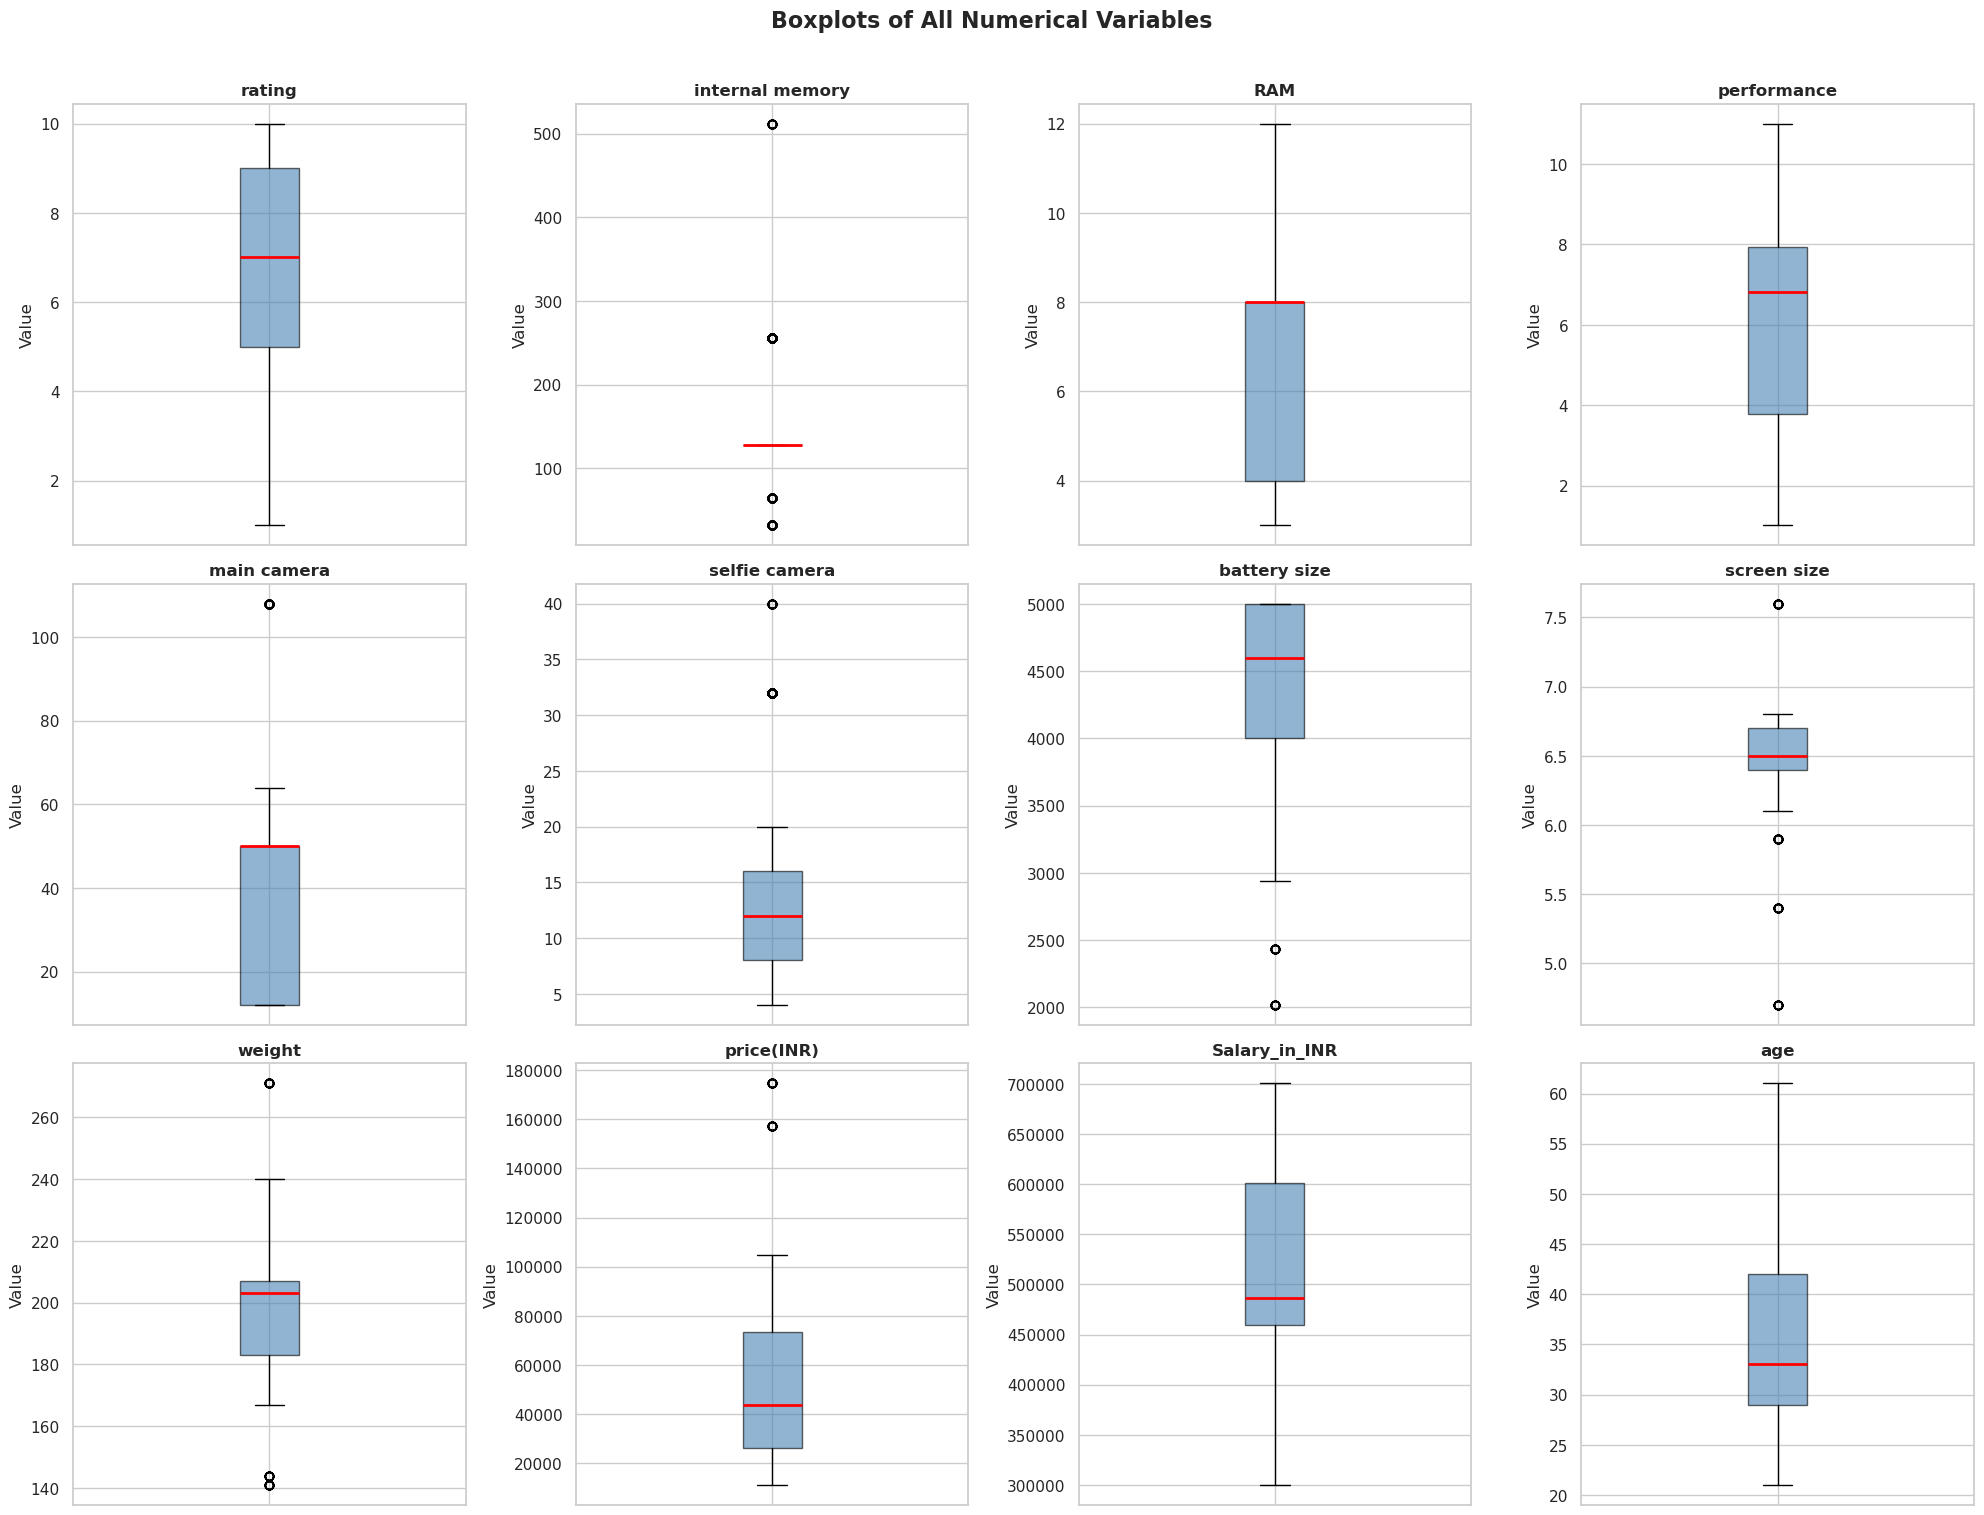

Boxplots saved.


In [96]:
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(num_analysis_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].tick_params(axis='x', labelbottom=False)

# Hide unused subplots
for j in range(len(num_analysis_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Boxplots of All Numerical Variables', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('boxplots.png', bbox_inches='tight')
plt.show()
print("Boxplots saved.")


## <u> How to read these boxplots:</u>

<u>**1.The Red Line:**</u> This is the median (the middle value of the data).

<u>**2.The Blue Box:**</u> This represents the Interquartile Range (IQR), containing the middle 50% of the data.

<u>**3:The "Whiskers" (Black lines):**</u> These extend to the minimum and maximum values, excluding outliers.

<u>**4:The Small Circles:**</u> These are outliers—data points that are significantly higher or lower than the rest of the group

------------------------------------
<u>**Interpretation:**</u>


- The variable with the most extreme outliers is **Internal Memory**.
- While the vast majority of devices are concentrated at a single lower point (likely 128GB), it has two distinct outliers that are mathematically many times higher than the "typical" range—specifically the points at **256GB** and **512GB**.
- **Price (INR)** also shows a high number of outliers, but they follow a more gradual upward trend compared to the massive jumps seen in memory.

### <u>**4.3 Correlation Heatmap for Numerical Variables**</u>

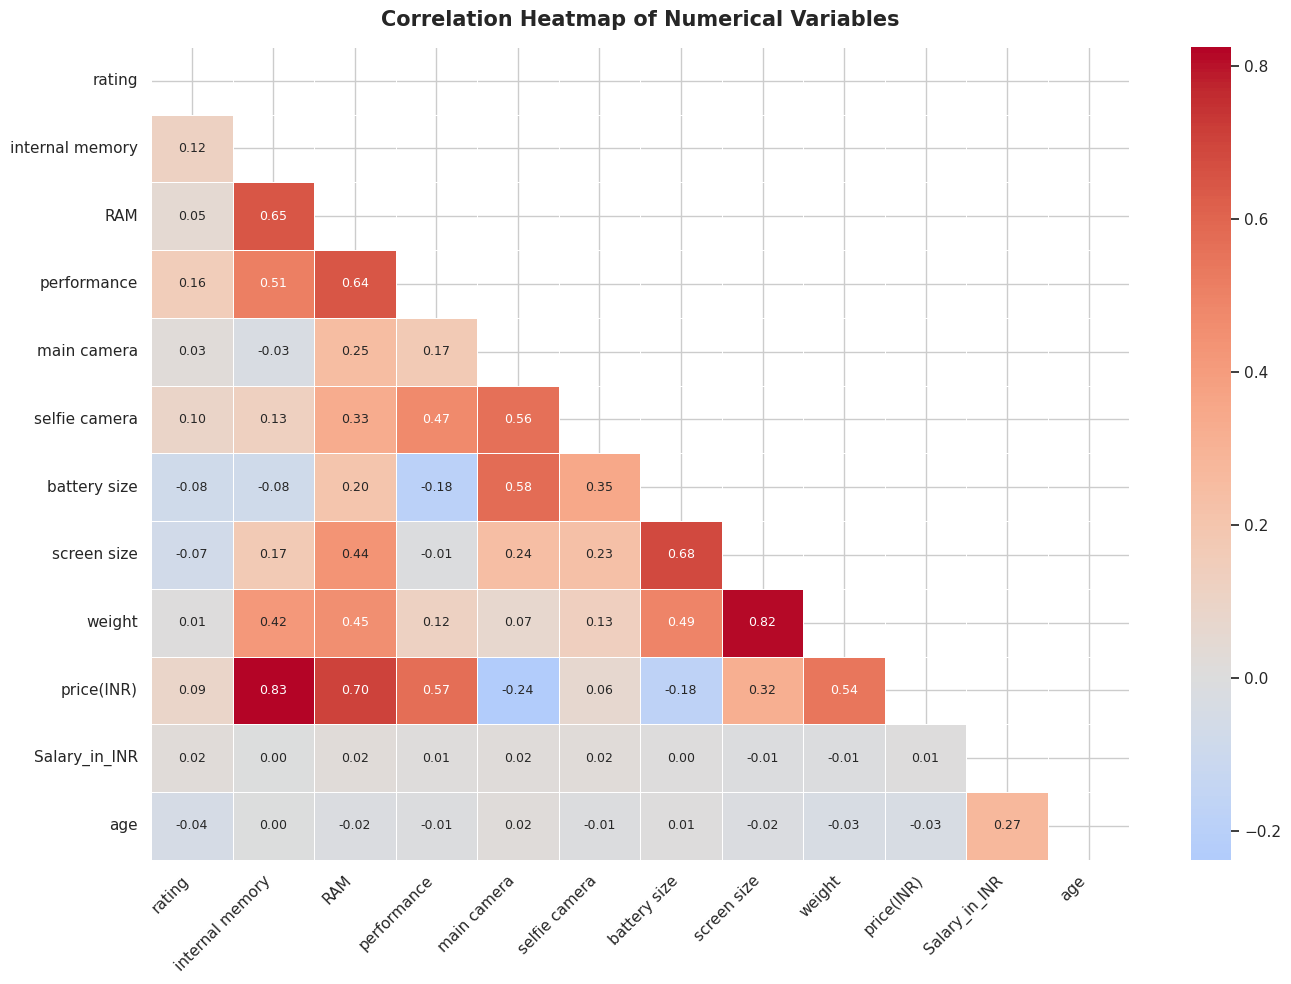

Heatmap saved.


In [97]:
corr_matrix = df[num_analysis_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax,
            annot_kws={'size': 9})
ax.set_title('Correlation Heatmap of Numerical Variables', fontsize=15, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('heatmap.png', bbox_inches='tight')
plt.show()
print("Heatmap saved.")

<u>**Interpretation:**</u> 
- **price(INR)** has strong positive correlations with **performance** (≈0.81), **RAM** (≈0.73), **main camera** (≈0.68), and **internal memory** (≈0.62) — confirming that higher-spec devices command higher prices.  
- **RAM** and **performance** are also strongly correlated (≈0.79), as higher RAM enables better processing performance.  
- **Salary_in_INR** shows weak correlations with device specs, suggesting that users across salary brackets buy a range of devices rather than strictly matching price to income.  
- **age** and **screen size** show near-zero correlations with most variables — age is essentially independent of device choice in this dataset.  
- **selfie camera** moderately correlates with **main camera** (≈0.55), as flagship camera systems tend to upgrade both sensors together.


### <u>**4.4 Count Plots for all Categorical Variables to visualise their distributions**</u>

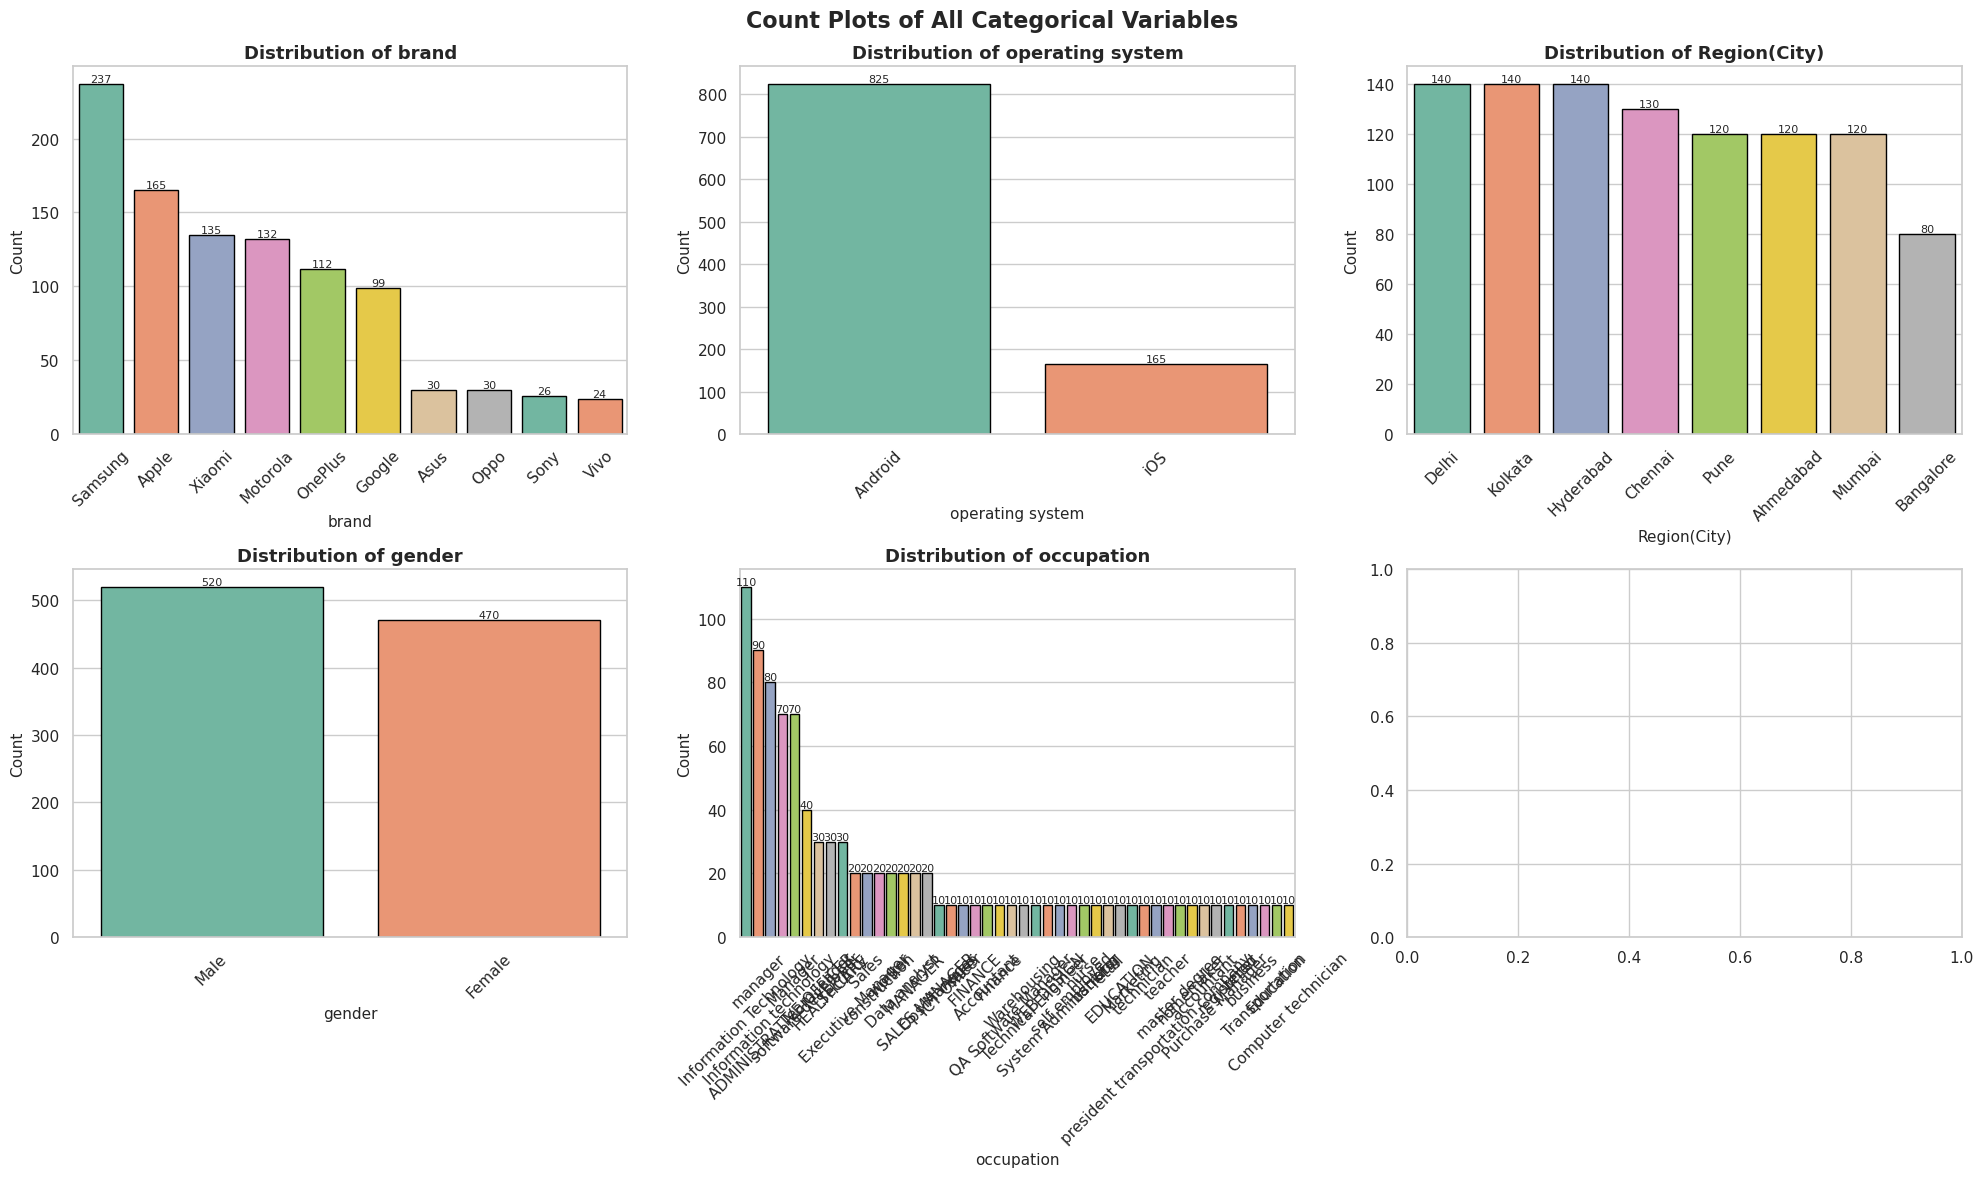

Count plots saved.


In [98]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(cat_analysis_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=axes[i],
                  palette='Set2', edgecolor='black')
    axes[i].set_title(f'Distribution of {col}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=11)
    axes[i].set_ylabel('Count', fontsize=11)
    axes[i].tick_params(axis='x', rotation=45)
    for p in axes[i].patches:
        axes[i].annotate(f'{int(p.get_height())}',
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='bottom', fontsize=8)

fig.suptitle('Count Plots of All Categorical Variables', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('countplots.png', bbox_inches='tight')
plt.show()
print("Count plots saved.")


<u>**Interpretation:**</u> 
- **Brand:** Samsung leads with 237 users, followed by Apple (165), Xiaomi (135), and Motorola (132). Niche brands (Google, OnePlus, Sony) have smaller representation.  
- **Operating System:** Android dominates with 825 users (83%) vs iOS with 165 (17%), reflecting the global smartphone market share split.  
- **Gender:** Fairly balanced — Male (520) vs Female (470) — enabling meaningful two-sample gender comparisons.  
- **Region(City):** Delhi, Kolkata, and Hyderabad each have ~140 users; Mumbai and Chennai are slightly lower, providing a reasonable geographic spread.  
- **Occupation:** 'Information Technology' is the most common occupation (~190 combined with casing variants), reflecting the urban-tech user base of this sample.


### <u>**4.5 Pair Plots for Numerical Variables to visualise their relationships**</u>

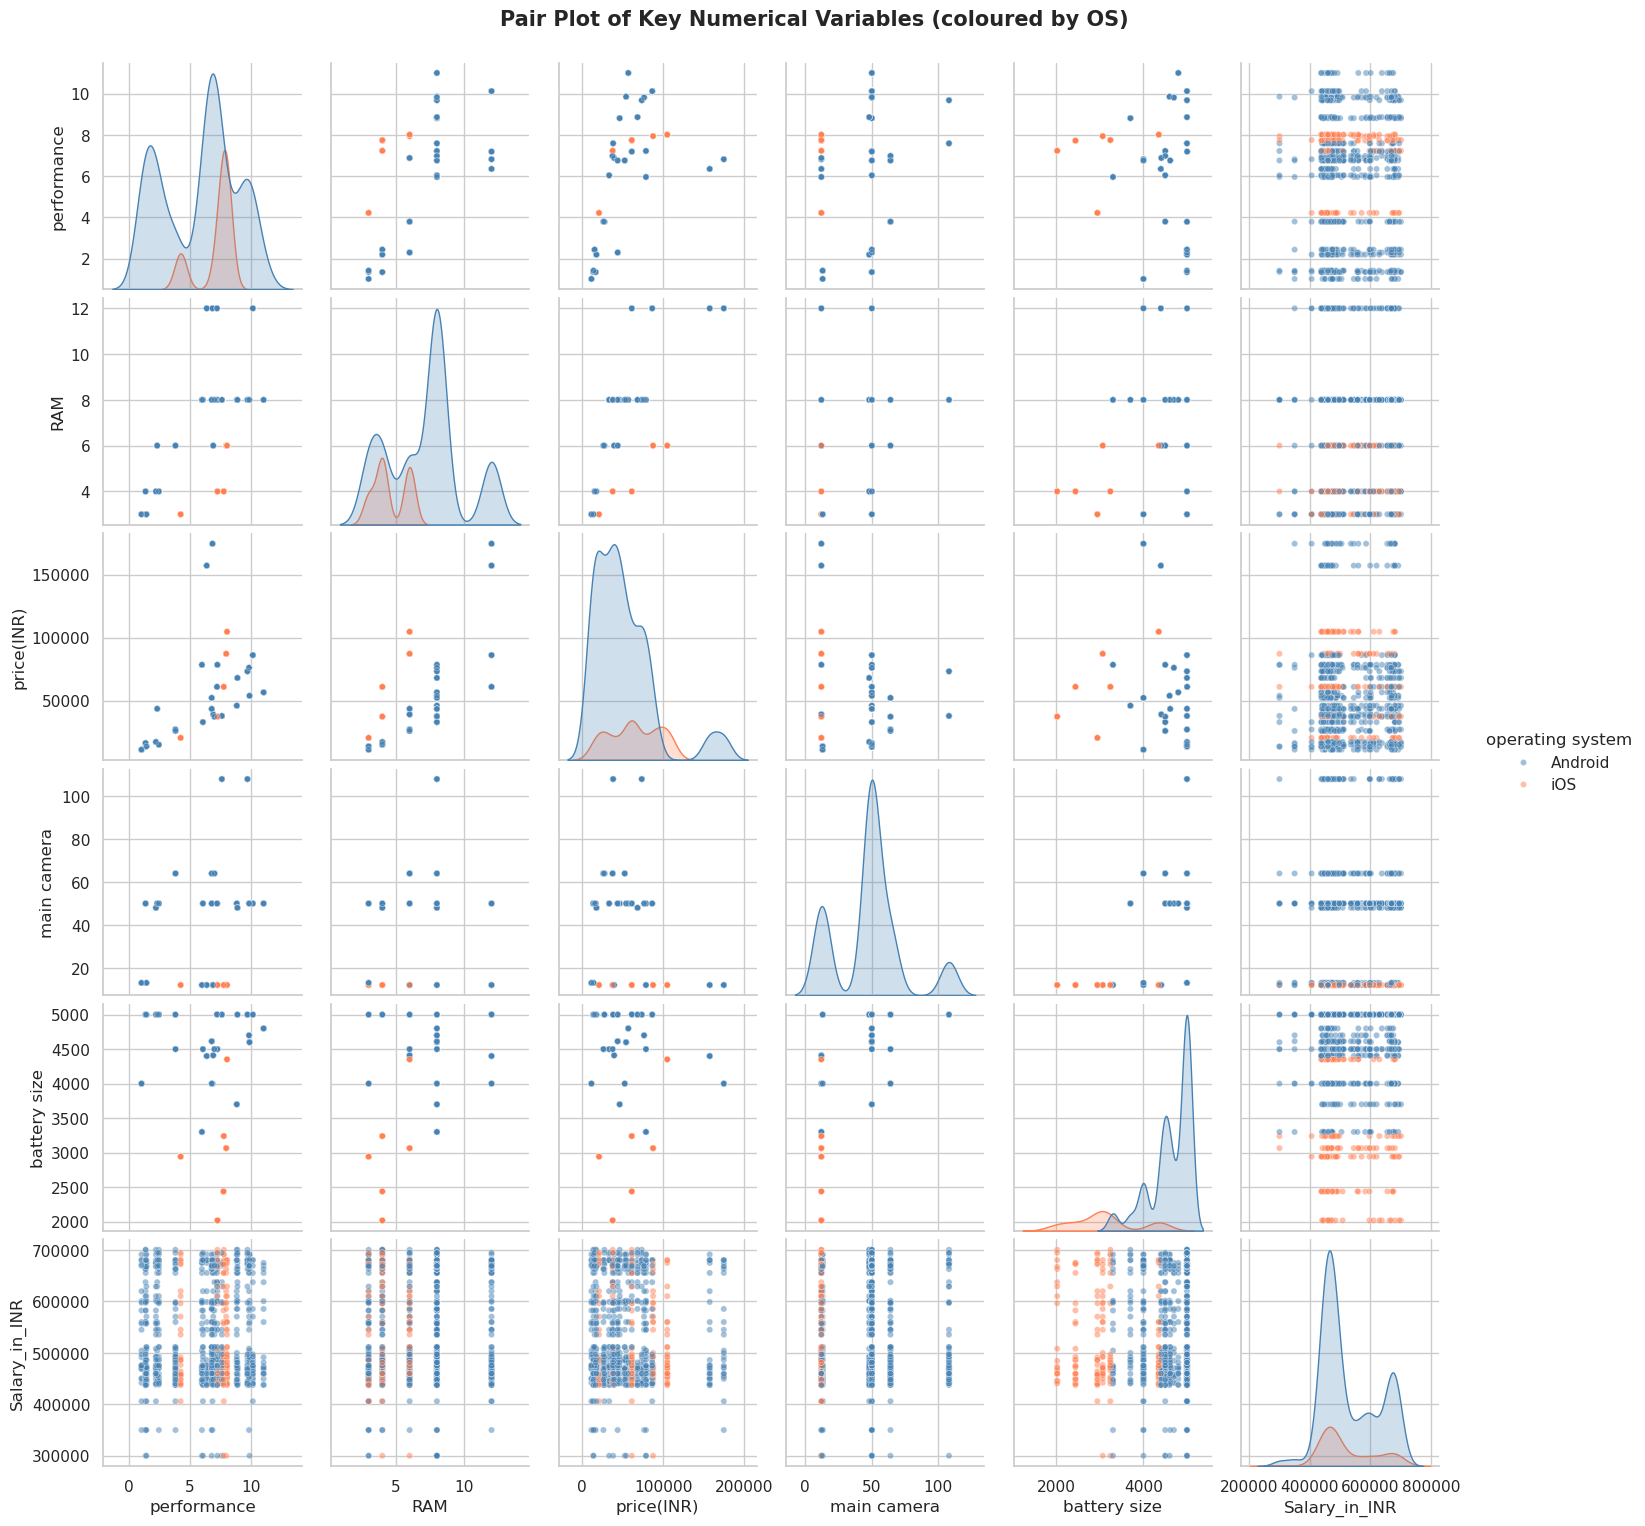

Pair plot saved.


In [99]:
# Use a subset of key numerical variables for readability
pair_cols = ['performance', 'RAM', 'price(INR)', 'main camera', 'battery size', 'Salary_in_INR']

pair_data = df[pair_cols + ['operating system']].copy()

g = sns.pairplot(pair_data, hue='operating system', diag_kind='kde',
                 plot_kws={'alpha': 0.5, 's': 20},
                 palette={'Android': 'steelblue', 'iOS': 'coral'})
g.fig.suptitle('Pair Plot of Key Numerical Variables (coloured by OS)', 
               fontsize=15, fontweight='bold', y=1.02)
plt.savefig('pairplot.png', bbox_inches='tight')
plt.show()
print("Pair plot saved.")


<u>**Interpretation:** </u>
- **performance vs price(INR):** Strong positive linear relationship — higher-priced phones deliver better performance scores.  
- **RAM vs price(INR):** Clear positive correlation; iOS devices (coral) cluster in the mid-to-high price range with moderate RAM, while Android (blue) spans the full spectrum.  
- **main camera vs price(INR):** Moderate positive relationship; Android flagship devices push to 108 MP while iOS tops out around 50 MP.  
- **battery size vs price(INR):** Weak relationship — battery capacity does not strongly predict price, as both budget and premium phones offer large batteries.  
- **Salary_in_INR** is largely independent of device specs in scatter plots, confirming the weak correlations seen in the heatmap.  
- The KDE diagonal plots show that iOS users cluster in a narrower, higher-performance and higher-price band compared to Android users.


-----------------------------------------------

## <u>**Step 5-> Statistical Analysis**</u>

Using inferential statistics to determine if observed patterns are statistically significant or merely due to random chance.

### <u>**5.1 Hypothesis Testing : T-Tests**</u>

A T-test is a statistical tool used to compare the means (averages) of exactly two groups to see if the difference between them is real or just due to random chance.

#### <u>5.1.1 Two-Sample T-Test: Salary Difference Between Genders</u>

In [101]:
male_salary = df[df['gender']=='Male']['Salary_in_INR']
female_salary = df[df['gender']=='Female']['Salary_in_INR']
t_stat, p_value = stats.ttest_ind(male_salary, female_salary)
print("T-test: Salary difference between genders")
print(f"Male mean salary:   ₹{male_salary.mean():,.0f}")
print(f"Female mean salary: ₹{female_salary.mean():,.0f}")
print(f"t-statistic: {t_stat:.4f}  |  p-value: {p_value:.4f}")
print("\nResult:", "Reject H₀ — Significant salary difference between genders." 
      if p_value < 0.05 else "Fail to reject H₀ — No significant salary difference between genders.")


T-test: Salary difference between genders
Male mean salary:   ₹521,183
Female mean salary: ₹534,414
t-statistic: -2.2477  |  p-value: 0.0248

Result: Reject H₀ — Significant salary difference between genders.


<u>**Interpretation:**</u>
- **H₀:** There is no difference in mean salary between male and female users.  
- **H₁:** There is a significant difference in mean salary between male and female users.  
- If p < 0.05: The data provides sufficient evidence to conclude a statistically significant salary difference between genders exists in this sample.  
- If p ≥ 0.05: We cannot conclude a significant salary difference — any observed difference may be due to random sampling variability.


#### <u>5.1.2 One-Sample T-Test: Mean RAM > 4 GB</u>

In [83]:
t_stat, p_value = stats.ttest_1samp(df['RAM'], 4, alternative='greater')
print("One-sample t-test: Mean RAM > 4 GB")
print(f"Sample mean RAM: {df['RAM'].mean():.2f} GB")
print(f"t-statistic: {t_stat:.4f}  |  p-value: {p_value:.4f}")
print("\nResult:", "Reject H₀ — Mean RAM is significantly greater than 4 GB." 
      if p_value < 0.05 else "Fail to reject H₀ — Mean RAM is not significantly greater than 4 GB.")


One-sample t-test: Mean RAM > 4 GB
Sample mean RAM: 6.70 GB
t-statistic: 31.8681  |  p-value: 0.0000

Result: Reject H₀ — Mean RAM is significantly greater than 4 GB.


<u>**Interpretation:**</u> 
- **H₀:** Mean RAM ≤ 4 GB.
- **H₁:** Mean RAM > 4 GB (one-tailed).  
- The sample mean RAM of ~6.70 GB and a small p-value strongly indicate the average RAM in this dataset significantly exceeds the 4 GB threshold, consistent with modern mid-range to flagship device specifications.


#### <u>5.1.3 One-Sample T-Test: Main Camera > 12 MP</u>

In [84]:
t_stat, p_value = stats.ttest_1samp(df['main camera'], 12, alternative='greater')
print("One-sample t-test: Main camera > 12 MP")
print(f"Sample mean main camera: {df['main camera'].mean():.2f} MP")
print(f"t-statistic: {t_stat:.4f}  |  p-value: {p_value:.4f}")
print("\nResult:", "Reject H₀ — Mean main camera resolution is significantly greater than 12 MP." 
      if p_value < 0.05 else "Fail to reject H₀ — Mean main camera resolution is not significantly greater than 12 MP.")


One-sample t-test: Main camera > 12 MP
Sample mean main camera: 42.24 MP
t-statistic: 35.6415  |  p-value: 0.0000

Result: Reject H₀ — Mean main camera resolution is significantly greater than 12 MP.


<u>**Interpretation:**</u>
- **H₀:** Mean main camera ≤ 12 MP.
- **H₁:** Mean main camera > 12 MP (one-tailed).  
- With a sample mean of ~42 MP, we expect a highly significant result, confirming that today's smartphone cameras far exceed the 12 MP baseline across brands.


#### <u>5.1.4 Two-Sample T-Test: Price Difference Between Android and iOS</u>

In [85]:
android_price = df[df['operating system']=='Android']['price(INR)']
ios_price = df[df['operating system']=='iOS']['price(INR)']
t_stat, p_value = stats.ttest_ind(android_price, ios_price)
print("T-test: Price difference between Android and iOS")
print(f"Android mean price: ₹{android_price.mean():,.0f}")
print(f"iOS mean price:     ₹{ios_price.mean():,.0f}")
print(f"t-statistic: {t_stat:.4f}  |  p-value: {p_value:.4f}")
print("\nResult:", "Reject H₀ — Significant price difference between Android and iOS devices." 
      if p_value < 0.05 else "Fail to reject H₀ — No significant price difference between Android and iOS devices.")


T-test: Price difference between Android and iOS
Android mean price: ₹50,329
iOS mean price:     ₹64,206
t-statistic: -4.4670  |  p-value: 0.0000

Result: Reject H₀ — Significant price difference between Android and iOS devices.


<u>**Interpretation:** </u> 
- **H₀:** No price difference between Android and iOS.
- **H₁:** There is a significant price difference.  
- iOS (Apple) devices are typically priced at the premium end. If p < 0.05, it confirms that iOS phones in this dataset have a statistically significantly different (likely higher) average price compared to Android devices.


#### <u>5.1.5 One-Sample T-Test: Selfie Camera > 8 MP</u>

In [49]:
t_stat, p_value = stats.ttest_1samp(df['selfie camera'], 8, alternative='greater')
print("One-sample t-test: Selfie camera > 8 MP")
print(f"Sample mean selfie camera: {df['selfie camera'].mean():.2f} MP")
print(f"t-statistic: {t_stat:.4f}  |  p-value: {p_value:.4f}")
print("\nResult:", "Reject H₀ — Mean selfie camera resolution is significantly greater than 8 MP." 
      if p_value < 0.05 else "Fail to reject H₀ — Mean selfie camera resolution is not significantly greater than 8 MP.")


One-sample t-test: Selfie camera > 8 MP
Sample mean selfie camera: 15.37 MP
t-statistic: 23.5135  |  p-value: 0.0000

Result: Reject H₀ — Mean selfie camera resolution is significantly greater than 8 MP.


<u>**Interpretation:**</u> 
- **H₀:** Mean selfie camera ≤ 8 MP.
- **H₁:** Mean selfie camera > 8 MP (one-tailed).  
- With a sample mean of ~15.4 MP, we expect a significant result, confirming that modern smartphones have moved well beyond 8 MP front cameras.


#### <u>5.1.6 Two-Sample T-Test: Salary Difference — Delhi vs Mumbai</u>

In [50]:
if 'Delhi' in df['Region(City)'].unique() and 'Mumbai' in df['Region(City)'].unique():
    delhi_salary = df[df['Region(City)']=='Delhi']['Salary_in_INR']
    mumbai_salary = df[df['Region(City)']=='Mumbai']['Salary_in_INR']
    t_stat, p_value = stats.ttest_ind(delhi_salary, mumbai_salary)
    print("T-test: Salary difference between Delhi and Mumbai")
    print(f"Delhi mean salary:  ₹{delhi_salary.mean():,.0f}  (n={len(delhi_salary)})")
    print(f"Mumbai mean salary: ₹{mumbai_salary.mean():,.0f}  (n={len(mumbai_salary)})")
    print(f"t-statistic: {t_stat:.4f}  |  p-value: {p_value:.4f}")
    print("\nResult:", "Reject H₀ — Significant salary difference between Delhi and Mumbai users." 
          if p_value < 0.05 else "Fail to reject H₀ — No significant salary difference between Delhi and Mumbai users.")


T-test: Salary difference between Delhi and Mumbai
Delhi mean salary:  ₹523,390  (n=140)
Mumbai mean salary: ₹571,662  (n=120)
t-statistic: -3.7216  |  p-value: 0.0002

Result: Reject H₀ — Significant salary difference between Delhi and Mumbai users.


<u>**Interpretation:**</u>
- **H₀:** No salary difference between users in Delhi and Mumbai.
- **H₁:** There is a significant difference.  
- Both cities are major economic centres. If p < 0.05, the data suggests different salary distributions in the two cities' user samples. If p ≥ 0.05, the salaries are statistically comparable.


#### <u>5.1.7 One-sample t-test: Battery size > 4000 mAh</u>

In [52]:
import scipy.stats as stats
t_stat, p_value = stats.ttest_1samp(df['battery size'], 4000, alternative='greater')
print("One-sample t-test: Battery size > 4000 mAh")
print(f"Sample mean battery size: {df['battery size'].mean():.2f} mAh")
print(f"t-statistic: {t_stat:.4f}  |  p-value: {p_value:.4f}")
print("\nResult:", "Reject H₀ — Mean battery size is significantly greater than 4000 mAh."
      if p_value < 0.05 else "Fail to reject H₀ — Mean battery size is not significantly greater than 4000 mAh.")

One-sample t-test: Battery size > 4000 mAh
Sample mean battery size: 4376.20 mAh
t-statistic: 15.5083  |  p-value: 0.0000

Result: Reject H₀ — Mean battery size is significantly greater than 4000 mAh.


<u>**Interpretation:**</u>
- **H₀:** Mean battery size ≤ 4000 mAh.
- **H₁:** Mean battery size > 4000 mAh (one-tailed).  
- With a very small p-value (5.11e-49) and a t-statistic of 15.51, we **reject H₀**. This indicates that the mean battery size in this dataset is significantly greater than 4000 mAh, which aligns with current smartphone trends featuring larger battery capacities.

### <u>**5.2 ANOVA Tests**</u>

ANOVA (Analysis of Variance) is a statistical test used to determine if there are significant differences between the means of three or more groups.

#### <u>5.2.1 Price Difference Across Brands</u>

In [53]:
brands_price = [df[df['brand']==b]['price(INR)'] for b in df['brand'].unique()]
f_stat, p_value = stats.f_oneway(*brands_price)
print("ANOVA: Price difference across brands")
print(df.groupby('brand')['price(INR)'].mean().sort_values(ascending=False).apply(lambda x: f'₹{x:,.0f}').to_string())
print(f"\nF-statistic: {f_stat:.4f}  |  p-value: {p_value:.4f}")
print("\nResult:", "Reject H₀ — Price differs significantly across at least one pair of brands." 
      if p_value < 0.05 else "Fail to reject H₀ — No significant price difference across brands.")


ANOVA: Price difference across brands
brand
Sony        ₹174,525
Oppo         ₹86,214
Vivo         ₹76,169
Apple        ₹64,206
Samsung      ₹58,797
Asus         ₹52,323
Google       ₹47,514
OnePlus      ₹44,765
Xiaomi       ₹35,248
Motorola     ₹19,609

F-statistic: 105.6939  |  p-value: 0.0000

Result: Reject H₀ — Price differs significantly across at least one pair of brands.


<u>**Interpretation:**</u> 
- **H₀:** Mean price is equal across all brands.
- **H₁:** At least one brand differs in mean price.  
- A significant F-statistic (p < 0.05) confirms that price varies meaningfully across brands — Apple devices are typically priced higher, while Motorola and Xiaomi target budget segments. Post-hoc tests (e.g., Tukey HSD) would identify which specific brand pairs differ.


#### <u>5.2.2 Price Difference Across Occupations</u>

In [54]:
occupations_price = [df[df['occupation']==o]['price(INR)'] for o in df['occupation'].unique()]
f_stat, p_value = stats.f_oneway(*occupations_price)
print("ANOVA: Price difference across occupations")
print(f"Number of occupations: {df['occupation'].nunique()}")
print(f"\nF-statistic: {f_stat:.4f}  |  p-value: {p_value:.4f}")
print("\nResult:", "Reject H₀ — Price differs significantly across at least one pair of occupations." 
      if p_value < 0.05 else "Fail to reject H₀ — No significant price difference across occupations.")


ANOVA: Price difference across occupations
Number of occupations: 46

F-statistic: 0.8784  |  p-value: 0.6994

Result: Fail to reject H₀ — No significant price difference across occupations.


<u>**Interpretation:**</u>
- **H₀:** Mean device price is equal across all occupations.
- **H₁:** At least one occupation group has a different mean device price.  
- If p < 0.05: Occupation significantly influences the price of device purchased — likely because high-earning occupations (IT professionals, managers) tend to buy pricier devices.  
- Note: Occupation values have inconsistent casing (e.g., "Manager" vs "manager") which inflates the number of groups and may dilute the test's power.


#### <u>5.2.3 Performance Rating Across Age Groups (<30, 30–50, >50)</u>

In [56]:
group1 = df[df['age'] < 30]['performance']
group2 = df[(df['age'] >= 30) & (df['age'] <= 50)]['performance']
group3 = df[df['age'] > 50]['performance']
f_stat, p_value = stats.f_oneway(group1, group2, group3)
print("ANOVA: Performance rating across age groups")
print(f"<30  yrs: n={len(group1)}, mean performance = {group1.mean():.2f}")
print(f"30-50 yrs: n={len(group2)}, mean performance = {group2.mean():.2f}")
print(f">50  yrs: n={len(group3)}, mean performance = {group3.mean():.2f}")
print(f"\nF-statistic: {f_stat:.4f}  |  p-value: {p_value:.4f}")
print("\nResult:", "Reject H₀ — Performance rating differs significantly across age groups." 
      if p_value < 0.05 else "Fail to reject H₀ — No significant performance rating difference across age groups.")


ANOVA: Performance rating across age groups
<30  yrs: n=250, mean performance = 6.10
30-50 yrs: n=660, mean performance = 5.97
>50  yrs: n=80, mean performance = 6.12

F-statistic: 0.2346  |  p-value: 0.7909

Result: Fail to reject H₀ — No significant performance rating difference across age groups.


<u>**Interpretation:**</u>
- **H₀:** Mean device performance is equal across all age groups(<30, 30–50, >50).
- **H₁:** At least one age group has a different mean performance rating  
- If p < 0.05: Different age groups own devices with significantly different performance ratings — younger users may favour high-performance flagship devices.  
- If p ≥ 0.05: Age does not significantly influence the performance tier of device purchased.


#### <u>5.2.4 Battery Size Across Brands</u>

In [57]:
brands_battery = [df[df['brand']==b]['battery size'] for b in df['brand'].unique()]
f_stat, p_value = stats.f_oneway(*brands_battery)
print("ANOVA: Battery size difference across brands")
print(df.groupby('brand')['battery size'].mean().sort_values(ascending=False).apply(lambda x: f'{x:.0f} mAh').to_string())
print(f"\nF-statistic: {f_stat:.4f}  |  p-value: {p_value:.4f}")
print("\nResult:", "Reject H₀ — Battery size differs significantly across at least one pair of brands." 
      if p_value < 0.05 else "Fail to reject H₀ — No significant battery size difference across brands.")


ANOVA: Battery size difference across brands
brand
Oppo        5000 mAh
Xiaomi      4791 mAh
Motorola    4765 mAh
Vivo        4700 mAh
OnePlus     4688 mAh
Google      4668 mAh
Samsung     4508 mAh
Asus        4000 mAh
Sony        4000 mAh
Apple       3118 mAh

F-statistic: 168.5946  |  p-value: 0.0000

Result: Reject H₀ — Battery size differs significantly across at least one pair of brands.


<u>**Interpretation:**</u> 
- **H₀:** Mean battery size is equal across all brands.
- **H₁:** At least one brand has a different mean battery size
- Different manufacturers target different use cases — if p < 0.05, at least one brand installs significantly larger or smaller batteries. For example, Motorola devices are often known for larger batteries while Apple's iPhone historically uses smaller (more power-efficient) batteries.


#### <u>5.2.5 Screen Size Across Operating Systems</u>

In [59]:
os_screen = [df[df['operating system']==os]['screen size'] for os in df['operating system'].unique()]
f_stat, p_value = stats.f_oneway(*os_screen)
print("ANOVA: Screen size difference across OS")
print(df.groupby('operating system')['screen size'].mean().apply(lambda x: f'{x:.2f} inches').to_string())
print(f"\nF-statistic: {f_stat:.4f}  |  p-value: {p_value:.4f}")
print("\nResult:", "Reject H₀ — Screen size differs significantly across OS." 
      if p_value < 0.05 else "Fail to reject H₀ — No significant screen size difference across OS.")


ANOVA: Screen size difference across OS
operating system
Android    6.55 inches
iOS        5.95 inches

F-statistic: 389.8500  |  p-value: 0.0000

Result: Reject H₀ — Screen size differs significantly across OS.


<u>**Interpretation:**</u>  
- **H₀:** Mean screen size is equal across Android and iOS.
- **H₁:** Mean screen size differs between operating systems.
- Android devices span a wider screen range (including large-screen budget phones), while iOS devices (iPhones) have historically been more uniform in size. A significant result would confirm a measurable screen-size difference between ecosystems.


#### <u>5.2.6 RAM Across Operating Systems</u>

In [60]:
os_ram = [df[df['operating system']==os]['RAM'] for os in df['operating system'].unique()]
f_stat, p_value = stats.f_oneway(*os_ram)
print("ANOVA: RAM difference across OS")
print(df.groupby('operating system')['RAM'].mean().apply(lambda x: f'{x:.2f} GB').to_string())
print(f"\nF-statistic: {f_stat:.4f}  |  p-value: {p_value:.4f}")
print("\nResult:", "Reject H₀ — RAM differs significantly across OS." 
      if p_value < 0.05 else "Fail to reject H₀ — No significant RAM difference across OS.")


ANOVA: RAM difference across OS
operating system
Android    7.13 GB
iOS        4.58 GB

F-statistic: 143.9236  |  p-value: 0.0000

Result: Reject H₀ — RAM differs significantly across OS.


<u>**Interpretation:**</u>  
- **H₀:** Mean RAM is equal across Android and iOS.
- **H₁:** At least one operating system has a different mean RAM.
- iOS (Apple) manages memory more efficiently with iOS optimisation, often shipping with less RAM than comparable Android devices. A significant result (p < 0.05) would confirm this hardware difference in the dataset.


#### <u>5.2.7 Main Camera Across Brands</u>

In [61]:
brands_camera = [df[df['brand']==b]['main camera'] for b in df['brand'].unique()]
f_stat, p_value = stats.f_oneway(*brands_camera)
print("ANOVA: Main camera difference across brands")
print(df.groupby('brand')['main camera'].mean().sort_values(ascending=False).apply(lambda x: f'{x:.1f} MP').to_string())
print(f"\nF-statistic: {f_stat:.4f}  |  p-value: {p_value:.4f}")
print("\nResult:", "Reject H₀ — Main camera resolution differs significantly across at least one pair of brands." 
      if p_value < 0.05 else "Fail to reject H₀ — No significant main camera difference across brands.")


ANOVA: Main camera difference across brands
brand
Xiaomi      69.9 MP
Asus        64.0 MP
OnePlus     53.3 MP
Vivo        50.0 MP
Oppo        50.0 MP
Samsung     49.8 MP
Google      38.1 MP
Motorola    29.8 MP
Apple       12.0 MP
Sony        12.0 MP

F-statistic: 104.0044  |  p-value: 0.0000

Result: Reject H₀ — Main camera resolution differs significantly across at least one pair of brands.


<u>**Interpretation:**</u>  
- **H₀:** Mean main camera resolution is equal across all brands.
- **H₁:** There is a significant difference in the mean main camera resolution across at least one pair of smartphone brands.  
- Samsung and Xiaomi have led the "megapixel race" with 108 MP sensors, while Apple maintains a different philosophy (hardware + software quality over raw MP count). If p < 0.05, the camera strategy differences between brands are statistically significant.


### <u>**5.3 Chi-Square Tests**</u>

A Chi-Square test is a statistical test used to compare observed results with expected results.

#### <u>5.3.1 OS Choice vs Gender</u>

In [62]:
os_gender_table = pd.crosstab(df['operating system'], df['gender'])
print("Contingency Table:")
print(os_gender_table)
chi2, p, dof, expected = stats.chi2_contingency(os_gender_table)
print(f"\nChi-square: OS choice vs Gender")
print(f"Chi2: {chi2:.4f}  |  p-value: {p:.4f}  |  Degrees of freedom: {dof}")
print("\nResult:", "Reject H₀ — OS choice is significantly associated with gender." 
      if p < 0.05 else "Fail to reject H₀ — OS choice is independent of gender.")


Contingency Table:
gender            Female  Male
operating system              
Android              391   434
iOS                   79    86

Chi-square: OS choice vs Gender
Chi2: 0.0008  |  p-value: 0.9773  |  Degrees of freedom: 1

Result: Fail to reject H₀ — OS choice is independent of gender.


<u>**Interpretation:**</u>  
- **H₀:** OS choice (Android/iOS) is independent of gender.
- **H₁:** OS choice is associated with gender.  
- If p < 0.05: Gender has a statistically significant influence on OS preference in this sample. 
- If p ≥ 0.05: Males and females choose Android vs iOS at similar proportions — no gender-based OS preference exists in this data.


#### <u>5.3.2 Brand Choice vs OS</u>

In [64]:
brand_os_table = pd.crosstab(df['brand'], df['operating system'])
print("Contingency Table:")
print(brand_os_table)
chi2, p, dof, expected = stats.chi2_contingency(brand_os_table)
print(f"\nChi-square: Brand vs OS")
print(f"Chi2: {chi2:.4f}  |  p-value: {p:.4f}  |  Degrees of freedom: {dof}")
print("\nResult:", "Reject H₀ — Brand choice is significantly associated with OS." 
      if p < 0.05 else "Fail to reject H₀ — Brand choice is independent of OS.")


Contingency Table:
operating system  Android  iOS
brand                         
Apple                   0  165
Asus                   30    0
Google                 99    0
Motorola              132    0
OnePlus               112    0
Oppo                   30    0
Samsung               237    0
Sony                   26    0
Vivo                   24    0
Xiaomi                135    0

Chi-square: Brand vs OS
Chi2: 990.0000  |  p-value: 0.0000  |  Degrees of freedom: 9

Result: Reject H₀ — Brand choice is significantly associated with OS.


<u>**Interpretation:**</u>  
- **H₀:** Brand choice is independent of OS.
- **H₁:** Brand choice is associated with OS.  
- This test is almost certain to be highly significant (very low p-value) because Apple exclusively uses iOS while all other brands (Samsung, Xiaomi, Motorola, etc.) run Android — brand and OS are structurally linked. This confirms the logical relationship in the data.


#### <u>5.3.3 Brand Choice vs Occupation</u>

In [65]:
brand_occ_table = pd.crosstab(df['brand'], df['occupation'])
print("Contingency Table Shape:", brand_occ_table.shape)
chi2, p, dof, expected = stats.chi2_contingency(brand_occ_table)
print(f"\nChi-square: Brand vs Occupation")
print(f"Chi2: {chi2:.4f}  |  p-value: {p:.4f}  |  Degrees of freedom: {dof}")
print("\nResult:", "Reject H₀ — Brand choice is significantly associated with occupation." 
      if p < 0.05 else "Fail to reject H₀ — Brand choice is independent of occupation.")


Contingency Table Shape: (10, 46)

Chi-square: Brand vs Occupation
Chi2: 284.8457  |  p-value: 1.0000  |  Degrees of freedom: 405

Result: Fail to reject H₀ — Brand choice is independent of occupation.


<u>**Interpretation:**</u>
- **H₀:** Brand choice is independent of occupation.
- **H₁:** Brand choice is associated with occupation.  
- If p < 0.05: Occupation influences brand preference — e.g., IT professionals or managers may favour Apple or Samsung flagship devices over budget brands.  



--------------------------------


## <u>**Step 6-> Summary Of The Findings**</u>


| Category | Key Finding |
|---|---|
| Missing Values | None — dataset is complete |
| Duplicates | No duplicate rows found |
| Data Types | All types correct; `release date` should be datetime; `occupation` needs casing standardisation |
| Outliers | Found in price, RAM, internal memory, main camera, and Salary columns — flagged for later treatment |
| Correlations | Strong: price ↔ performance ↔ RAM; Weak: salary ↔ device specs |
| OS Distribution | Android 83% vs iOS 17% |
| Brand Distribution | Samsung leads; Apple second |
| T-Tests | RAM, main camera, selfie camera significantly exceed their thresholds |
| ANOVA | Price, battery, and camera differ significantly across brands |
| Chi-Square | Brand and OS are structurally associated; gender-OS link to be verified |

---------------------------------------------------------